# Strawberry Pickability Classifier

MLP Neural Network menggunakan sklearn.neural_network.MLPClassifier
Dataset: Pickable vs UnPickable strawberry images

Pipeline:
  1. Load images & extract color + texture features (64-dim)
  2. Train/Test split (80/20, stratified)
  3. StandardScaler normalization
  4. MLPClassifier training dengan early stopping
  5. Evaluation: accuracy, classification report, confusion matrix
  6. 5-fold cross validation
  7. Save model

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

  Strawberry Pickability — MLP Classifier

[1/5] Loading dataset ...
  Loading Pickable: 263 images ...
  Loading UnPickable: 258 images ...
  Dataset  : 521 samples  |  64 features
  Pickable : 263  |  UnPickable : 258

[2/5] Splitting data (80/20 stratified) ...
  Train : 416  |  Test : 105

[3/5] Training MLPClassifier ...
  Done in 0.2s  |  Iterations : 27

[4/5] Evaluating on test set ...

  Test Accuracy : 98.10%

              precision    recall  f1-score   support

  UnPickable     0.9808    0.9808    0.9808        52
    Pickable     0.9811    0.9811    0.9811        53

    accuracy                         0.9810       105
   macro avg     0.9810    0.9810    0.9810       105
weighted avg     0.9810    0.9810    0.9810       105

  Confusion Matrix:
[[51  1]
 [ 1 52]]

[5/5] 5-Fold Cross Validation ...
  Scores : [85.71 99.04 96.15 98.08 99.04]
  Mean   : 95.60%  ±  5.06%

[6/6] Saving model ...
  Model saved → strawberry_mlp_model.pkl


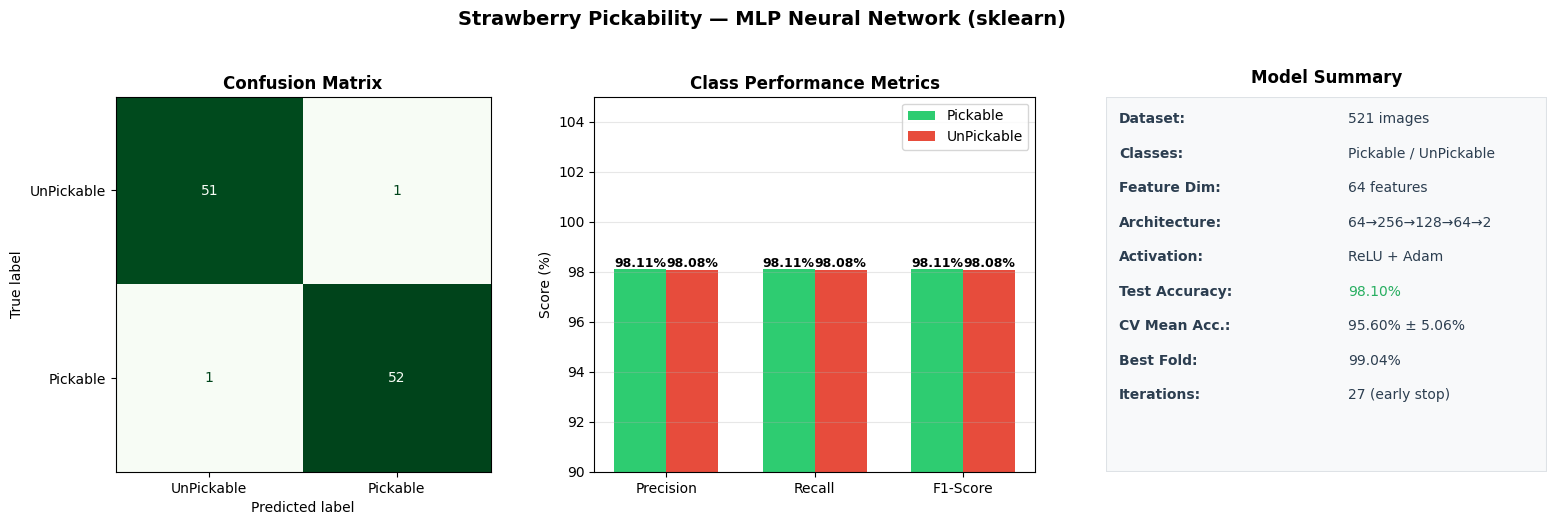


Plot saved → strawberry_mlp_results.png


In [3]:
from IPython import display
# CONFIGURATION
DATASET_PATH = "strawberryDataset"
IMG_SIZE     = (224, 224)
TEST_SIZE    = 0.20
RANDOM_STATE = 42

MLP_CONFIG = dict(
    hidden_layer_sizes = (256, 128, 64),
    activation         = 'relu',
    solver             = 'adam',
    alpha              = 0.001,
    learning_rate_init = 0.001,
    max_iter           = 300,
    random_state       = RANDOM_STATE,
    early_stopping     = True,
    validation_fraction= 0.1,
    n_iter_no_change   = 15,
)


# FEATURE EXTRACTION
def extract_features(img_path: str, size=IMG_SIZE) -> np.ndarray:
    """
    Mengekstrak 64 fitur dari satu gambar:
      - Mean, std, Q1, Q3 per channel R/G/B         → 12 fitur
      - Rasio warna (redness ratio, green/blue)      →  2 fitur
      - Histogram 16 bin per channel R/G/B           → 48 fitur
      - Grayscale mean & std (tekstur)               →  2 fitur
    Total: 64 fitur
    """
    img = Image.open(img_path).convert("RGB").resize(size)
    arr = np.array(img, dtype=np.float32) / 255.0
    r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]

    feats = []

    # Statistik per channel
    for ch in [r, g, b]:
        feats += [ch.mean(), ch.std(),
                  np.percentile(ch, 25), np.percentile(ch, 75)]

    # Rasio warna
    feats.append(r.mean() / (g.mean() + 1e-6))
    feats.append(g.mean() / (b.mean() + 1e-6))

    # Histogram
    for ch in [r, g, b]:
        hist, _ = np.histogram(ch, bins=16, range=(0, 1))
        feats += (hist / hist.sum()).tolist()

    # Grayscale mean & std
    gray = np.array(img.convert("L"), dtype=np.float32) / 255.0
    feats += [gray.mean(), gray.std()]

    return np.array(feats, dtype=np.float32)


# LOAD DATASET
def load_dataset(base_path: str):
    classes = [("Pickable", 1), ("UnPickable", 0)]
    X, y = [], []
    for cls_name, label in classes:
        folder = os.path.join(base_path, cls_name)
        files  = sorted(os.listdir(folder))
        print(f"  Loading {cls_name}: {len(files)} images ...")
        for fn in files:
            try:
                fv = extract_features(os.path.join(folder, fn))
                X.append(fv)
                y.append(label)
            except Exception as e:
                print(f"    ⚠  Skip {fn}: {e}")
    return np.array(X), np.array(y)


# MAIN
if __name__ == "__main__":
    print("=" * 55)
    print("  Strawberry Pickability — MLP Classifier")
    print("=" * 55)

    # 1. Load
    print("\n[1/5] Loading dataset ...")
    X, y = load_dataset(DATASET_PATH)
    print(f"  Dataset  : {X.shape[0]} samples  |  {X.shape[1]} features")
    print(f"  Pickable : {y.sum()}  |  UnPickable : {(y == 0).sum()}")

    # 2. Split
    print("\n[2/5] Splitting data (80/20 stratified) ...")
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    print(f"  Train : {len(X_tr)}  |  Test : {len(X_te)}")

    # 3. Scale
    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_te_s   = scaler.transform(X_te)
    X_all_s  = scaler.fit_transform(X)

    # 4. Train MLP
    print("\n[3/5] Training MLPClassifier ...")
    mlp = MLPClassifier(**MLP_CONFIG)
    t0  = time.time()
    mlp.fit(X_tr_s, y_tr)
    elapsed = time.time() - t0
    print(f"  Done in {elapsed:.1f}s  |  Iterations : {mlp.n_iter_}")

    # 5. Evaluate
    print("\n[4/5] Evaluating on test set ...")
    y_pred = mlp.predict(X_te_s)
    acc    = accuracy_score(y_te, y_pred)
    print(f"\n  Test Accuracy : {acc * 100:.2f}%")
    print("\n" + classification_report(y_te, y_pred,
          target_names=["UnPickable", "Pickable"], digits=4))
    print("  Confusion Matrix:")
    print(confusion_matrix(y_te, y_pred))

    # 6. Cross-validation
    print("\n[5/5] 5-Fold Cross Validation ...")
    cv = cross_val_score(MLPClassifier(**MLP_CONFIG), X_all_s, y, cv=5, scoring='accuracy')
    print(f"  Scores : {np.round(cv * 100, 2)}")
    print(f"  Mean   : {cv.mean() * 100:.2f}%  ±  {cv.std() * 100:.2f}%")

    # 7. Save model
    print("\n[6/6] Saving model ...")
    joblib.dump(mlp, "strawberry_mlp_model.pkl")
    print("  Model saved → strawberry_mlp_model.pkl")

    # PLOT RESULTS
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Strawberry Pickability — MLP Neural Network (sklearn)",
                 fontsize=14, fontweight='bold', y=1.02)
 
    # Confusion Matrix
    ax1 = axes[0]
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=["UnPickable", "Pickable"]
    ).plot(ax=ax1, colorbar=False, cmap='Greens')
    ax1.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
 
    # Metrics Bar
    ax2 = axes[1]
    precision = precision_score(y_te, y_pred, average=None)
    recall    = recall_score(y_te, y_pred, average=None)
    f1        = f1_score(y_te, y_pred, average=None)

    metrics = ['Precision', 'Recall', 'F1-Score']
    pickable = [precision[1]*100, recall[1]*100, f1[1]*100]
    unpickable = [precision[0]*100, recall[0]*100, f1[0]*100]

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = ax2.bar(x - width/2, pickable, width,
                    label='Pickable', color='#2ecc71')

    bars2 = ax2.bar(x + width/2, unpickable, width,
                    label='UnPickable', color='#e74c3c')

    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics)
    ax2.set_ylabel('Score (%)')
    ax2.set_ylim(90, 105)
    ax2.set_title('Class Performance Metrics',
                fontweight='bold', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # Label nilai
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2,
                h + 0.1,
                f'{h:.2f}%',
                ha='center',
                fontsize=9,
                fontweight='bold')
    
    # Model Summary
    ax3 = axes[2]
    ax3.axis('off')
    summary = [
        ('Dataset',       f'{X.shape[0]} images'),
        ('Classes',       'Pickable / UnPickable'),
        ('Feature Dim',   f'{X.shape[1]} features'),
        ('Architecture',  '64→256→128→64→2'),
        ('Activation',    'ReLU + Adam'),
        ('Test Accuracy', f'{acc*100:.2f}%'),
        ('CV Mean Acc.',  f'{cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%'),
        ('Best Fold',     f'{cv.max()*100:.2f}%'),
        ('Iterations',    f'{mlp.n_iter_} (early stop)'),
    ]
    ax3.set_title('Model Summary', fontweight='bold', fontsize=12, pad=10)
    ax3.add_patch(plt.Rectangle((0, 0), 1, 1, fill=True, facecolor='#f8f9fa',
                                 edgecolor='#dee2e6', lw=1.5,
                                 transform=ax3.transAxes, zorder=0))
    for i, (k, v) in enumerate(summary):
        yp = 0.93 - i * 0.092
        ax3.text(0.03, yp, k + ':', transform=ax3.transAxes,
                 fontsize=10, fontweight='bold', color='#2c3e50', zorder=1)
        ax3.text(0.55, yp, v, transform=ax3.transAxes, fontsize=10,
                 color='#27ae60' if 'Accuracy' in k or 'AUC' in k else '#2c3e50', zorder=1)
 
    plt.tight_layout()
    plt.savefig('strawberry_mlp_results.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("\nPlot saved → strawberry_mlp_results.png")


Predicted: UnPickable  |  Probability: 99.96%


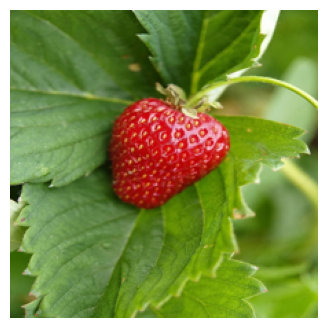

In [4]:
def load_image(img_path: str, size=IMG_SIZE) -> np.ndarray:
    img = Image.open(img_path).convert("RGB").resize(size)
    return np.array(img)

def predict_image(img_path: str, model: MLPClassifier, scaler: StandardScaler):
    plt.figure(figsize=(4, 4))
    plt.imshow(load_image(img_path))
    plt.axis('off')
    fv = extract_features(img_path).reshape(1, -1)
    fv_s = scaler.transform(fv)
    pred = model.predict(fv_s)[0]
    prob = model.predict_proba(fv_s)[0][pred]
    return pred, prob

model = joblib.load("strawberry_mlp_model.pkl")
pred, prob = predict_image("testingDataset/matang.webp", model, scaler)
print(f"\nPredicted: {'Pickable' if pred == 1 else 'UnPickable'}  |  Probability: {prob*100:.2f}%")


Predicted: UnPickable  |  Probability: 99.65%


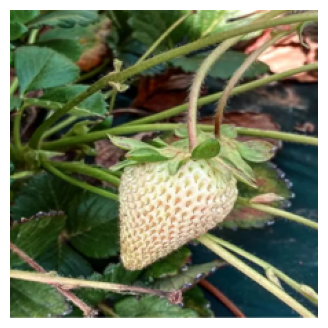

In [5]:
pred2, prob2 = predict_image("testingDataset/mentah.webp", model, scaler)
print(f"\nPredicted: {'Pickable' if pred2 == 1 else 'UnPickable'}  |  Probability: {prob2*100:.2f}%")